# Homework for Lab 3.3 

## 3.3.1 SimCLR on STL-10


In [1]:
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import v2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


In [2]:
# Dataset hyperparameters
unlabeled_dataset_size = 10000 # Actually 100000, but we will limit the size here for sake of training time
labeled_dataset_size = 5000
image_channels = 3

# Algorithm hyperparameters
num_epochs = 20
batch_size = 512
width = 128
temperature = 0.1
num_workers = 2

contrastive_augmentation = {'min_area': 0.25, 'brightness': 0.6, 'jitter': 0.2}
classification_augmentation = {'min_area': 0.75, 'brightness': 0.3, 'jitter': 0.1}

#### Dataset

In [3]:
from torch.utils.data import Subset
import numpy as np

to_image = v2.ToImage()


def get_subset(dataset, fraction):
    n = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), n, replace=False)
    return Subset(dataset, indices)

def prepare_datasets(amount = 1, data_root='./data'):
    unlabeled_train_dataset_full = datasets.STL10(
        root=data_root,
        split='unlabeled',
        download=True,
        transform=to_image,
    )
    labeled_train_dataset = datasets.STL10(
        root=data_root,
        split='train',
        download=True,
        transform=to_image,
    )
    test_dataset = datasets.STL10(
        root=data_root,
        split='test',
        download=True,
        transform=to_image,
    )

    # only get the passed size of dataset
    unlabeled_train_dataset = get_subset(unlabeled_train_dataset_full, amount)
    steps_per_epoch = (unlabeled_dataset_size + labeled_dataset_size) // batch_size
    unlabeled_batch_size = unlabeled_dataset_size // steps_per_epoch
    labeled_batch_size = labeled_dataset_size // steps_per_epoch
    print(f'batch size is {unlabeled_batch_size} (unlabeled) + {labeled_batch_size} (labeled)')

    unlabeled_loader = DataLoader(
        unlabeled_train_dataset, batch_size=unlabeled_batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True
    )
    labeled_loader = DataLoader(
        labeled_train_dataset, batch_size=labeled_batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return unlabeled_loader, labeled_loader, test_loader


In [5]:
unlabeled_loader10, labeled_loader, test_loader = prepare_datasets(0.1)
unlabeled_loader20, labeled_loader, test_loader = prepare_datasets(0.2)
unlabeled_loader30, labeled_loader, test_loader = prepare_datasets(0.3)
unlabeled_loader40, labeled_loader, test_loader = prepare_datasets(0.4)


batch size is 344 (unlabeled) + 172 (labeled)
batch size is 344 (unlabeled) + 172 (labeled)
batch size is 344 (unlabeled) + 172 (labeled)
batch size is 344 (unlabeled) + 172 (labeled)


In [6]:
print(f" 10% : {len(unlabeled_loader10.dataset)}")
print(f" 20% : {len(unlabeled_loader20.dataset)}")
print(f" 30% : {len(unlabeled_loader30.dataset)}")
print(f" 40% : {len(unlabeled_loader40.dataset)}")

 10% : 10000
 20% : 20000
 30% : 30000
 40% : 40000


#### Augmentations

In [7]:
def get_augmenter(min_area, brightness, jitter):
    return v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(96, 96), scale=(min_area, 1.0), antialias=True),
        v2.ColorJitter(brightness=brightness, contrast=jitter, saturation=jitter, hue=min(0.5, jitter)),
    ])

def get_eval_transform():
    return v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
    ])

contrastive_transform = get_augmenter(**contrastive_augmentation)
classification_transform = get_augmenter(**classification_augmentation)
eval_transform = get_eval_transform()

#### Encoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, width=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=2),
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.LazyLinear(width)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = F.relu(self.fc(x))
        return x

def get_encoder():
    return Encoder(width=width)

#### Training

In [9]:
class ContrastiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = get_encoder()
        self.projection_head = nn.Sequential(
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, width),
        )

    def encode_project(self, x):
        feats = self.encoder(x)
        proj = self.projection_head(feats)
        return feats, proj

def contrastive_loss_and_acc(z1, z2, temperature=0.1):

    # z1, z2 are two batches of projected embeddings corresponding to two augmented views of the same batch of images
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # The contrastive loss is computed by treating each pair of corresponding samples in z1 and z2 as positive pairs, and all other combinations as negative pairs.
    # The logits are computed as the cosine similarity (dot product of normalized vectors) divided by the temperature.
    logits = z1 @ z2.T / temperature

    # The labels for the contrastive loss are simply the indices of the samples in the batch, since each sample's positive pair is at the same index in the other view, i.e., positive pairs are on the diagonal of the logits matrix, and all off-diagonal pairs are negative.
    labels = torch.arange(z1.size(0), device=z1.device)

    # The loss is computed as the average of the cross-entropy loss for predicting the correct positive pair from z1 to z2 and from z2 to z1.
    loss12 = F.cross_entropy(logits, labels)
    loss21 = F.cross_entropy(logits.T, labels)

    # Averaging the two losses encourages the model to learn symmetric representations that are invariant to the augmentations applied to the input images.
    loss = 0.5 * (loss12 + loss21)

    # The accuracy metrics acc12 and acc21 measure how often the highest-similarity index is the correct paired sample in each direction. This is not downstream classification accuracy!
    acc12 = (logits.argmax(dim=1) == labels).float().mean()
    acc21 = (logits.T.argmax(dim=1) == labels).float().mean()
    acc = 0.5 * (acc12 + acc21)
    return loss, acc


def train_contrastive(model, unl_loader, lbl_loader, val_loader, epochs=20, lr=1e-3):
    model = model.to(device)
    contrastive_params = list(model.encoder.parameters()) + list(model.projection_head.parameters())
    contrastive_opt = torch.optim.Adam(contrastive_params, lr=lr)

    hist = {'c_loss': [], 'c_acc': [], 'p_loss': [], 'p_acc': [], 'val_p_loss': [], 'val_p_acc': []}
    all_c_loss_epoch = []
    all_c_acc_epoch = []
    for ep in range(1, epochs + 1):
        model.train()

        c_loss_sum = 0.0
        c_acc_sum = 0.0
        p_loss_sum = 0.0
        p_acc_sum = 0.0
        steps = 0

        for (u_x, _), (l_x, l_y) in zip(unl_loader, lbl_loader):
            u_x = u_x.to(device, non_blocking=True)
            l_x = l_x.to(device, non_blocking=True)
            l_y = l_y.to(device, non_blocking=True)

            images = torch.cat([u_x, l_x], dim=0)
            # first batch of augmented images
            x1 = contrastive_transform(images)
            # second batch of augmented images
            x2 = contrastive_transform(images)

            contrastive_opt.zero_grad(set_to_none=True)
            _, z1 = model.encode_project(x1)
            _, z2 = model.encode_project(x2)

            # compute contastive loss and accuracy
            c_loss, c_acc = contrastive_loss_and_acc(z1, z2, temperature=temperature)
            c_loss.backward()
            contrastive_opt.step()



            c_loss_sum += c_loss.item()
            c_acc_sum += c_acc.item()
            steps += 1

        c_loss_epoch = c_loss_sum / max(steps, 1)
        c_acc_epoch = c_acc_sum / max(steps, 1)
        p_loss_epoch = p_loss_sum / max(steps, 1)


        hist['c_loss'].append(c_loss_epoch)
        hist['c_acc'].append(c_acc_epoch)
        hist['p_loss'].append(p_loss_epoch)

        all_c_loss_epoch.append(c_loss_epoch)
        all_c_acc_epoch.append(c_acc_epoch)
    
    print(
        f'[Pretrain] Epoch {ep:02d}/{epochs} - c_loss {np.mean(all_c_loss_epoch):.4f} - c_acc {np.mean(all_c_acc_epoch):.4f} '
    )

    return model, hist


#### Pre-training for differente unlabeled dataset sizes

In [10]:
# 10%
pretraining_model_10 = ContrastiveModel()
pretraining_model_10, pretraining_history_10 = train_contrastive(
    pretraining_model_10,
    unlabeled_loader10,
    labeled_loader,
    test_loader,
    epochs=num_epochs,
)

# 20%
pretraining_model_20 = ContrastiveModel()
pretraining_model_20, pretraining_history_20 = train_contrastive(
    pretraining_model_20,
    unlabeled_loader20,
    labeled_loader,
    test_loader,
    epochs=num_epochs,
)

# 30%
pretraining_model_30 = ContrastiveModel()
pretraining_model_30, pretraining_history_30 = train_contrastive(
    pretraining_model_30,
    unlabeled_loader30,
    labeled_loader,
    test_loader,
    epochs=num_epochs,
)

# 40%
pretraining_model_40 = ContrastiveModel()
pretraining_model_40, pretraining_history_40 = train_contrastive(
    pretraining_model_40,
    unlabeled_loader40,
    labeled_loader,
    test_loader,
    epochs=num_epochs,
)


[Pretrain] Epoch 20/20 - c_loss 5.3487 - c_acc 0.0817 
[Pretrain] Epoch 20/20 - c_loss 4.6901 - c_acc 0.1719 
[Pretrain] Epoch 20/20 - c_loss 5.2627 - c_acc 0.0912 
[Pretrain] Epoch 20/20 - c_loss 5.1443 - c_acc 0.0924 


##### Outputs
[Pretrain] 10% - Epoch 20/20 - c_loss 5.3487 - c_acc 0.0817   
[Pretrain] 20% - Epoch 20/20 - c_loss 4.6901 - c_acc 0.1719   
[Pretrain] 30% - Epoch 20/20 - c_loss 5.2627 - c_acc 0.0912   
[Pretrain] 40% - Epoch 20/20 - c_loss 5.1443 - c_acc 0.0924  

 #### Fine-tuning on Classifier

##### Model

In [11]:
class FinetuneClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(width, 10)

    def forward(self, x):
        return self.head(self.encoder(x))



##### Training for each proportion

In [14]:
@torch.no_grad()
def evaluate_classifier(model, loader, eval_tf):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x = eval_tf(x)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / max(total, 1), correct / max(total, 1)

def train_supervised(model, train_loader, val_loader, train_tf, eval_tf, epochs=20, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    all_va_loss = []
    all_va_acc = []
    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        tr_total = 0
        tr_correct = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            x = train_tf(x)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

            bs = y.size(0)
            tr_loss += loss.item() * bs
            tr_total += bs
            tr_correct += (logits.argmax(dim=1) == y).sum().item()

        tr_loss /= max(tr_total, 1)
        tr_acc = tr_correct / max(tr_total, 1)
        va_loss, va_acc = evaluate_classifier(model, val_loader, eval_tf)
        all_va_loss.append(va_loss)
        all_va_acc.append(va_acc)

        hist['loss'].append(tr_loss)
        hist['acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)

    print(f'[Baseline] Epoch {ep:02d}/{epochs} - loss {np.mean(all_va_loss):.4f} - acc {tr_acc:.4f} - val_acc {np.mean(all_va_acc):.4f}')

    return model, hist

In [15]:
# 10%
finetuning_model_10 = FinetuneClassifier(pretraining_model_10.encoder)
finetuning_model_10, finetuning_history_10 = train_supervised(
    finetuning_model_10,
    labeled_loader,
    test_loader,
    train_tf=classification_transform,
    eval_tf=eval_transform,
    epochs=num_epochs,
)
print(f"Max validation accuracy: {max(finetuning_history_10['val_acc']) * 100:.2f}%")

# 20%
finetuning_model_20 = FinetuneClassifier(pretraining_model_10.encoder)
finetuning_model_20, finetuning_history_20 = train_supervised(
    finetuning_model_20,
    labeled_loader,
    test_loader,
    train_tf=classification_transform,
    eval_tf=eval_transform,
    epochs=num_epochs,
)
print(f"Max validation accuracy: {max(finetuning_history_20['val_acc']) * 100:.2f}%")

# 30%
finetuning_model_30 = FinetuneClassifier(pretraining_model_10.encoder)
finetuning_model_30, finetuning_history_30 = train_supervised(
    finetuning_model_30,
    labeled_loader,
    test_loader,
    train_tf=classification_transform,
    eval_tf=eval_transform,
    epochs=num_epochs,
)
print(f"Max validation accuracy: {max(finetuning_history_30['val_acc']) * 100:.2f}%")

# 40%
finetuning_model_40 = FinetuneClassifier(pretraining_model_10.encoder)
finetuning_model_40, finetuning_history_40 = train_supervised(
    finetuning_model_40,
    labeled_loader,
    test_loader,
    train_tf=classification_transform,
    eval_tf=eval_transform,
    epochs=num_epochs,
)
print(f"Max validation accuracy: {max(finetuning_history_40['val_acc']) * 100:.2f}%")

[Baseline] Epoch 20/20 - loss 1.3782 - acc 0.5591 - val_acc 0.4926
Max validation accuracy: 54.89%
[Baseline] Epoch 20/20 - loss 1.2749 - acc 0.6506 - val_acc 0.5396
Max validation accuracy: 59.49%
[Baseline] Epoch 20/20 - loss 1.2190 - acc 0.7135 - val_acc 0.5734
Max validation accuracy: 61.04%
[Baseline] Epoch 20/20 - loss 1.2061 - acc 0.7821 - val_acc 0.5934
Max validation accuracy: 62.70%


##### Outputs
10 % - loss 1.3782 - val_acc 0.4926
    
20% - loss 1.2749 - val_acc 0.5396
    
30% - loss 1.2190 - val_acc 0.5734
  
40% - loss 1.2061 - val_acc 0.5934
  

### Baseline

In [16]:
class BaselineClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = get_encoder()
        self.head = nn.Linear(width, 10)

    def forward(self, x):
        return self.head(self.encoder(x))

@torch.no_grad()
def evaluate_classifier(model, loader, eval_tf):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x = eval_tf(x)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / max(total, 1), correct / max(total, 1)

def train_supervised(model, train_loader, val_loader, train_tf, eval_tf, epochs=20, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        tr_total = 0
        tr_correct = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            x = train_tf(x)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

            bs = y.size(0)
            tr_loss += loss.item() * bs
            tr_total += bs
            tr_correct += (logits.argmax(dim=1) == y).sum().item()

        tr_loss /= max(tr_total, 1)
        tr_acc = tr_correct / max(tr_total, 1)
        va_loss, va_acc = evaluate_classifier(model, val_loader, eval_tf)

        hist['loss'].append(tr_loss)
        hist['acc'].append(tr_acc)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)

        print(f'[Baseline] Epoch {ep:02d}/{epochs} - loss {tr_loss:.4f} - acc {tr_acc:.4f} - val_acc {va_acc:.4f}')

    return model, hist

baseline_model = BaselineClassifier()
baseline_model, baseline_history = train_supervised(
    baseline_model,
    labeled_loader,
    test_loader,
    train_tf=classification_transform,
    eval_tf=eval_transform,
    epochs=num_epochs,
)
print(f"Max validation accuracy: {max(baseline_history['val_acc']) * 100:.2f}%")

[Baseline] Epoch 01/20 - loss 2.2337 - acc 0.1688 - val_acc 0.1951
[Baseline] Epoch 02/20 - loss 2.0262 - acc 0.2548 - val_acc 0.3321
[Baseline] Epoch 03/20 - loss 1.8450 - acc 0.3232 - val_acc 0.3272
[Baseline] Epoch 04/20 - loss 1.7954 - acc 0.3374 - val_acc 0.3756
[Baseline] Epoch 05/20 - loss 1.7031 - acc 0.3741 - val_acc 0.4074
[Baseline] Epoch 06/20 - loss 1.6479 - acc 0.3945 - val_acc 0.3975
[Baseline] Epoch 07/20 - loss 1.5854 - acc 0.4030 - val_acc 0.4251
[Baseline] Epoch 08/20 - loss 1.5662 - acc 0.4166 - val_acc 0.4405
[Baseline] Epoch 09/20 - loss 1.5439 - acc 0.4314 - val_acc 0.4522
[Baseline] Epoch 10/20 - loss 1.5368 - acc 0.4302 - val_acc 0.4331
[Baseline] Epoch 11/20 - loss 1.4950 - acc 0.4465 - val_acc 0.4652
[Baseline] Epoch 12/20 - loss 1.4474 - acc 0.4619 - val_acc 0.4743
[Baseline] Epoch 13/20 - loss 1.4989 - acc 0.4433 - val_acc 0.4551
[Baseline] Epoch 14/20 - loss 1.4355 - acc 0.4603 - val_acc 0.4780
[Baseline] Epoch 15/20 - loss 1.4276 - acc 0.4689 - val_acc 0.

##### Outputs

[Baseline] Epoch 01/20 - loss 2.2337 - acc 0.1688 - val_acc 0.1951  
[Baseline] Epoch 02/20 - loss 2.0262 - acc 0.2548 - val_acc 0.3321  
[Baseline] Epoch 03/20 - loss 1.8450 - acc 0.3232 - val_acc 0.3272  
[Baseline] Epoch 04/20 - loss 1.7954 - acc 0.3374 - val_acc 0.3756  
[Baseline] Epoch 05/20 - loss 1.7031 - acc 0.3741 - val_acc 0.4074  
[Baseline] Epoch 06/20 - loss 1.6479 - acc 0.3945 - val_acc 0.3975  
[Baseline] Epoch 07/20 - loss 1.5854 - acc 0.4030 - val_acc 0.4251  
[Baseline] Epoch 08/20 - loss 1.5662 - acc 0.4166 - val_acc 0.4405  
[Baseline] Epoch 09/20 - loss 1.5439 - acc 0.4314 - val_acc 0.4522  
[Baseline] Epoch 10/20 - loss 1.5368 - acc 0.4302 - val_acc 0.4331  
[Baseline] Epoch 11/20 - loss 1.4950 - acc 0.4465 - val_acc 0.4652  
[Baseline] Epoch 12/20 - loss 1.4474 - acc 0.4619 - val_acc 0.4743  
[Baseline] Epoch 13/20 - loss 1.4989 - acc 0.4433 - val_acc 0.4551  
[Baseline] Epoch 14/20 - loss 1.4355 - acc 0.4603 - val_acc 0.4780  
[Baseline] Epoch 15/20 - loss 1.4276 - acc 0.4689 - val_acc 0.4831  
[Baseline] Epoch 16/20 - loss 1.4512 - acc 0.4653 - val_acc 0.4798  
[Baseline] Epoch 17/20 - loss 1.3672 - acc 0.4898 - val_acc 0.4946  
[Baseline] Epoch 18/20 - loss 1.2991 - acc 0.5180 - val_acc 0.5121  
[Baseline] Epoch 19/20 - loss 1.2708 - acc 0.5231 - val_acc 0.5131  
[Baseline] Epoch 20/20 - loss 1.2956 - acc 0.5188 - val_acc 0.4760  
Max validation accuracy: 51.31%

## 3.3.2 Journey through Representations

Since the 40% proportion results in better classification loss and accuracy, we will be choosing this one for this part.

Here, we want to compare representations of the Baseline and the SimCLR 40% encoder using t-SNE.

##### Baseline

In [18]:
all_repr = []
all_labels = []

baseline_model.encoder.eval()

# extract feature
with torch.no_grad():
    for x, y in labeled_loader:
        x = x.to(device).float() # here cuda
        z = baseline_model.encoder(x)

        all_repr.append(z.cpu())
        all_labels.append(y)

# concatenate batch results 
baseline_representations = torch.cat(all_repr, dim=0).numpy()
baseline_labels = torch.cat(all_labels, dim=0).numpy()

##### SimCLR 40%

In [21]:
all_repr = []
all_labels = []

finetuning_model_40.encoder.eval()

# extract feature
with torch.no_grad():
    for x, y in labeled_loader:
        x = x.to(device).float() # here cuda
        z = finetuning_model_40.encoder(x)

        all_repr.append(z.cpu())
        all_labels.append(y)

# concatenate batch results 
simclr_representations = torch.cat(all_repr, dim=0).numpy()
simclr_labels = torch.cat(all_labels, dim=0).numpy()


In [22]:
# merge all representations and labels for plot
all_representations = np.concatenate(
    [baseline_representations, simclr_representations],
    axis=0
)

all_labels = np.concatenate(
    [baseline_labels, simclr_labels],
    axis=0
)

In [23]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
representations_2d = tsne.fit_transform(all_representations)

In [24]:
# split to tell appart simclr and baseline in the plot
n_baseline = len(baseline_representations)

baseline_2d = representations_2d[:n_baseline]
simclr_2d = representations_2d[n_baseline:]

baseline_labels = all_labels[:n_baseline]
simclr_labels = all_labels[n_baseline:]

#### Plot

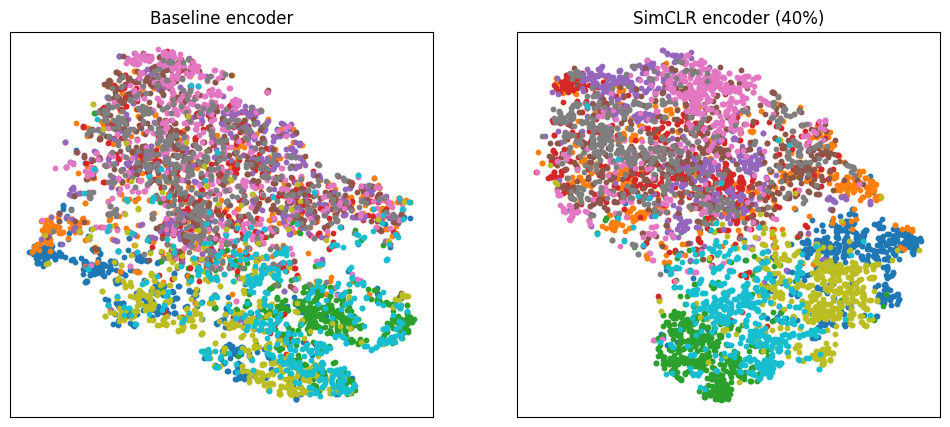

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Baseline
plt.subplot(1,2,1)

for c in range(10):
    idx = baseline_labels == c
    plt.scatter(
        baseline_2d[idx,0],
        baseline_2d[idx,1],
        s=10,
        label=str(c)
    )

plt.title("Baseline encoder")
plt.xticks([])
plt.yticks([])

# SimCLR
plt.subplot(1,2,2)

for c in range(10):
    idx = simclr_labels == c
    plt.scatter(
        simclr_2d[idx,0],
        simclr_2d[idx,1],
        s=10,
        label=str(c)
    )

plt.title("SimCLR encoder (40%)")
plt.xticks([])
plt.yticks([])

plt.show()

#### Conclusion

SimCLR (40%) is more precise and the "close" representation are closer than with the Baseline encoder aswell as the different representation are more strictly separated with SimCLR. 
The linear classifier of SimCLR accentuate the classification made by the encoder: in that way, the separation between images form different classes and vice versa is more clear.

spherical heatmap of the distribution per classe
spherical embedding -> projection à plat